# MACC Figure and Analysis Generation
This script will create the necessary figures and analysis for marginal abatement cost curves 
### Table of Contents
* Establish constants/read libraries
* Fundamental Calculations
  * Read/Prepare data
  * Calculate closest solar/wind CFs
  * Calculate US MACC
* Analysis
  * Plot US MACC
  * Maps
    * All decisions
    * Gas combined cycle replacements
    * Gas single cycle replacements
  * State level curves
  * Upfront costs
  * Effectiveness of carbon taxes

## Establish constants/read libraries

In [1]:

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance
import geopandas as gpd
import seaborn as sns

# This should eventually be moved to an __init__.py file 
sys.path.insert(0, './functions/')
sys.path.insert(0, './data/')
import read_data as rd
import cost 
import replacement
import constants
import plotMACC

%matplotlib inline
%load_ext autoreload
%autoreload 2


## Fundamental Calculations
### Read/Prepare data

In [2]:
# Read data
plant_data, cost_data, cf_data, age_data, emisisons_data, pv_cf_data, wind_cf_data = rd.read_data(os.getcwd())
plant_data = rd.clean_plant_data(plant_data)

# Format costs, capacity factors, and emissions as dicts to be fed into functions 
cost_dict = cost_data.to_dict("dict")
cf_dict = dict(zip(cf_data.index, cf_data.capacity_factor.values))
emissions_dict = dict(zip(emisisons_data.index, emisisons_data.co2_lb_per_mmbtu.values*constants.lb_kg*constants.kg_tonne/constants.mmbtu_btu))

### Calculate closest solar/wind CFs

In [3]:
points = plant_data.loc[:, ["lat", "lon"]].values
pv_locs = pv_cf_data[["latitude", "longitude"]].values
wind_locs = wind_cf_data[["latitude", "longitude"]].values

pv_cfs = replacement.select_cf(points, pv_locs, pv_cf_data["capacity_factor"].values)
wind_cfs = replacement.select_cf(points, wind_locs, wind_cf_data["capacity_factor"].values)

hold_dict = cf_dict.copy()
hold_dict["Solar"] = pv_cfs
hold_dict["Wind"] = wind_cfs


### Calculate US MACC

In [4]:
plant_data["rep_fuel"], plant_data["metric"], plant_data["em_red"] = replacement.replacement_df(plant_data, cost_dict, hold_dict, emissions_dict, 0, 0.06, 30, metric=1)
US_MACC = replacement.set_macc(plant_data, neg_cap = -200, cap = 200)
US_MACC["ori_rep"] = US_MACC["ori_rep"].replace("CC_|SC_", "", regex = True) 

c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\jonat\OneDrive\Desktop\General\School\Stanford\Research\MACC\MACCpy\./functions\replacement.py:310: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\jonat\OneDrive\Desktop\General\School\Stanford\Research\MACC\MACCpy\./functions\replacement.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

## Analysis
  * Plot US MACC
  * Maps
    * All decisions
    * Gas combined cycle replacements
    * Gas single cycle replacements
  * State level curves
  * Upfront costs

### Plot US MACC

c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:719: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:722: PlotnineWarning: Filename: c:\Users\jonat\OneDrive\Desktop\General\School\Stanford\Research\MACC\MACCpy\output\NationalCurves\2022_fuel.png


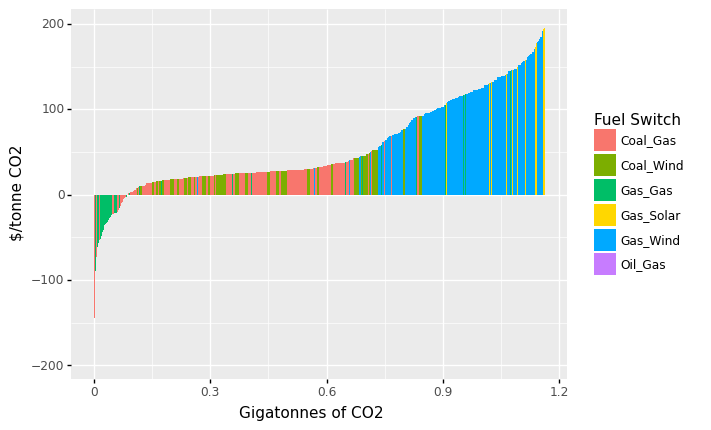

<ggplot: (147850091391)>

In [5]:
plotMACC.plot_MACC(US_MACC, title = "", x_lab = "Gigatonnes of CO2", save = True, file=os.path.join(os.getcwd(), "output", "NationalCurves", "2022_fuel.png"))

### Maps
#### All decisions

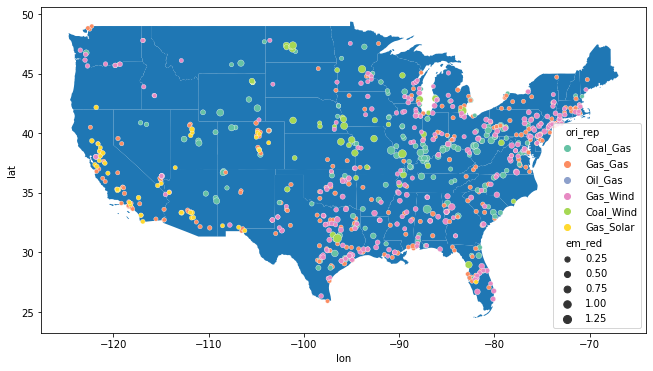

In [6]:
zipfile = "zip://"+os.path.join(os.getcwd(), "data", "raw", "mapping", "cb_2018_us_state_20m.zip")
states = gpd.read_file(zipfile)

fig, ax = plt.subplots(1, figsize=(20, 6))
states[states.NAME.isin(constants.US_CONTINENTAL)].plot(ax = ax)

sns.scatterplot(data=US_MACC, x="lon", y="lat", hue="ori_rep", size = "em_red", palette = "Set2")
plt.savefig("output\\rep_map.png", dpi = 600)

#### Gas combined cycle replacements

<AxesSubplot:xlabel='lon', ylabel='lat'>

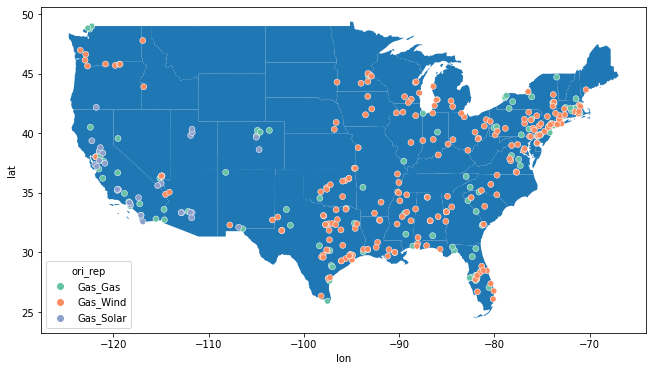

In [7]:
fig, ax = plt.subplots(1, figsize=(20, 6))
states[states.NAME.isin(constants.US_CONTINENTAL)].plot(ax = ax)

US_MACC_gas = US_MACC[US_MACC["primary_fuel"].isin(["Gas_CC"])]
sns.scatterplot(data=US_MACC_gas, x="lon", y="lat", hue="ori_rep", palette = "Set2")
# plt.savefig("output\\rep_map.png", dpi = 600)

#### Gas single cycle replacements

<AxesSubplot:xlabel='lon', ylabel='lat'>

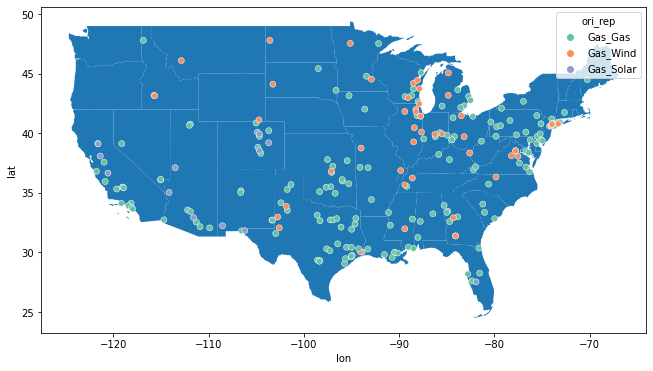

In [8]:
fig, ax = plt.subplots(1, figsize=(20, 6))
states[states.NAME.isin(constants.US_CONTINENTAL)].plot(ax = ax)

US_MACC_gas = US_MACC[US_MACC["primary_fuel"].isin(["Gas_SC"])]
sns.scatterplot(data=US_MACC_gas, x="lon", y="lat", hue="ori_rep", palette = "Set2")
# plt.savefig("output\\rep_map.png", dpi = 600)

### State level curves

In [9]:
states = US_MACC.state.unique()
for state in states:
    plotMACC.highlight_state(US_MACC, state, title = "", x_lab = "Gigatonnes of CO2", file = os.path.join(os.getcwd(), "output", "StateCurves", state+"_MACC_all.png"))

    state_subset = plant_data[plant_data.state == state]

    
    hold_dict["Solar"] = pv_cfs[plant_data.reset_index().state == state]
    hold_dict["Wind"] = wind_cfs[plant_data.reset_index().state == state]

    state_subset["rep_fuel"], state_subset["metric"], state_subset["em_red"] = replacement.replacement_df(state_subset, cost_dict, hold_dict, emissions_dict, 0, 0.06, 30, metric=1)
    STATE_MACC = replacement.set_macc(state_subset, neg_cap = -200, cap = 200)
    STATE_MACC["ori_rep"] = STATE_MACC["ori_rep"].replace("CC_|SC_", "", regex = True) 
    plotMACC.plot_MACC(STATE_MACC, title = "", x_lab = "Gigatonnes of CO2", save = True, file=os.path.join(os.getcwd(), "output", "StateCurves", state+"_MACC.png"))

c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\core\indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:719: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\plotnine\ggplot.py:722: PlotnineWarning: Filename: c:\Users\jonat\OneDrive\Desktop\General\School\Stanford\Research\MACC\MACCpy\output\StateCurves\NY_MACC_all.png
C:\Users\jonat\AppData\Local\Temp\ipykernel_48664\354963807.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

### Upfront costs

In [18]:
plant_inital_capital = plant_data["capacity"].values*1000*plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]).values
loc_cfs = np.zeros(len(plant_data))
for i in range(len(plant_data)):
    fuel = plant_data.reset_index().loc[i, "rep_fuel"]
    if fuel == "Gas":
        loc_cfs[i] = 0.65
    else:
        loc_cfs[i] = pv_cfs[i] if fuel == "Solar" else wind_cfs[i]


rep_initial_capital = plant_data.reset_index()["rep_fuel"].map(cost_dict["capital_cost_per_kw"])*replacement.size_capacity(plant_data.reset_index()["generation"], pd.Series(loc_cfs))
remain_cap = cost.remaining_capital(plant_inital_capital, 2020-plant_data["commissioning_year"].values, 0.06, 30)

initial_payment = remain_cap + rep_initial_capital
plant_data["remaining_cap"] = remain_cap
plant_data["upfront_cost"] = initial_payment.values


In [14]:
cols = ["metric", "capacity", "generation", "emissions", "em_red"]
threshholds = [0, 25, 50, 100] # $/tonne tax

US_MACC_costs = replacement.set_macc(plant_data, neg_cap = -200, cap = 200)
tot = plant_data[cols].sum(axis=0)

cum_results = pd.DataFrame()
for threshhold in threshholds:
    print("At a $"+str(threshhold)+" per tonne carbon price upfront costs of cost effective replacements would be "+str(round(US_MACC_costs[US_MACC_costs.metric<= threshhold]["upfront_cost"].sum(axis=0)/1E9, 3))+" Billion Dollars")
    print("At a $"+str(threshhold)+" per tonne carbon price average upfront costs (capacity weighted) of cost effective replacements would be "+str(round((US_MACC_costs[US_MACC_costs.metric<= threshhold]["upfront_cost"]*US_MACC_costs[US_MACC_costs.metric<= threshhold]["capacity"]).sum(axis=0)/(1E9*US_MACC_costs[US_MACC_costs.metric<= threshhold]["capacity"].sum(axis=0)), 3))+" Billion Dollars")
cum_results



At a $0 per tonne carbon price upfront costs of cost effective replacements would be 46.643 Billion Dollars
At a $0 per tonne carbon price average upfront costs (capacity weighted) of cost effective replacements would be 0.312 Billion Dollars
At a $25 per tonne carbon price upfront costs of cost effective replacements would be 161.753 Billion Dollars
At a $25 per tonne carbon price average upfront costs (capacity weighted) of cost effective replacements would be 0.758 Billion Dollars
At a $50 per tonne carbon price upfront costs of cost effective replacements would be 330.971 Billion Dollars
At a $50 per tonne carbon price average upfront costs (capacity weighted) of cost effective replacements would be 1.193 Billion Dollars
At a $100 per tonne carbon price upfront costs of cost effective replacements would be 572.401 Billion Dollars
At a $100 per tonne carbon price average upfront costs (capacity weighted) of cost effective replacements would be 1.618 Billion Dollars


""


## Percent impact from taxes
Percentage of capacity, generation, emissions, and emissions reductions. The emissions row tells you what fraction of emissions have been affected while em_red tells you the actual percentage of emissions reduced. Eg if at $25/tonne 10% of emissions have been affected (but some of those replacements were to gas) then only 5% of emissions were reduced.

In [15]:
tot = plant_data[cols].sum(axis=0)

cum_results = pd.DataFrame()
for threshhold in threshholds:
    cum_results[str(threshhold)] = plant_data[plant_data.metric<= threshhold][cols].sum(axis=0).div(tot)
    cum_results.at["em_red", str(threshhold)] = cum_results.loc["em_red", str(threshhold)]*tot["em_red"]/tot["emissions"]
cum_results

,0,25,50,100
metric,1.546297,1.540907,1.530485,1.503586
capacity,0.277279,0.425953,0.570321,0.698178
generation,0.093001,0.260188,0.488432,0.666761
emissions,0.105693,0.352391,0.665263,0.792377
em_red,0.058557,0.244787,0.465679,0.575921


### State level remaining capital 

In [33]:
state_remaining_capital = plant_data.groupby(["state", "primary_fuel"])[["state", "primary_fuel", "remaining_cap"]].sum().reset_index().sort_values("state")

import plotly.express as px

fig = px.bar(state_remaining_capital, x='state', y='remaining_cap', color = "primary_fuel", category_orders={"state":list(np.unique(state_remaining_capital.state))})

fig.update_xaxes(
    tickvals=np.unique(state_remaining_capital.state),
    title_text = "State"
)
fig.update_yaxes(
    title_text = "Remaining Capital (US $2021)"
)
fig.show()

# fig.write_image("output/remaining_capital.png")